## Code: Bell State Generation

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

sim = AerSimulator()

def create_bell_state(state_type):
    qc = QuantumCircuit(2)

    # Step 1: Create superposition
    qc.h(0)

    # Step 2: Entangle
    qc.cx(0, 1)

    if state_type == "phi_minus":
        qc.z(0)
    elif state_type == "psi_plus":
        qc.x(1)
    elif state_type == "psi_minus":
        qc.x(1)
        qc.z(0)

    return qc

# Generate all Bell states
states = ["phi_plus", "phi_minus", "psi_plus", "psi_minus"]

for s in states:
    qc = create_bell_state(s)
    sv = Statevector.from_instruction(qc)
    print(f"\nState: {s}")
    print(sv)


State: phi_plus
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

State: phi_minus
Statevector([ 0.70710678+0.j, -0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))

State: psi_plus
Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))

State: psi_minus
Statevector([ 0.        +0.j, -0.70710678+0.j,  0.70710678+0.j,
             -0.        +0.j],
            dims=(2, 2))


## Quantum Teleportation

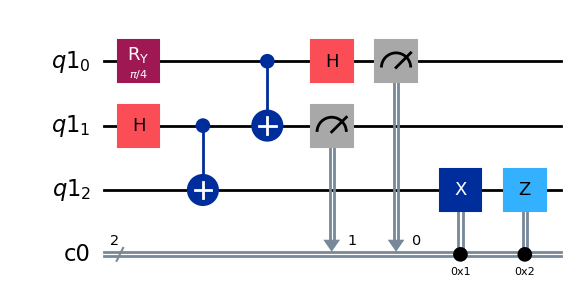

In [2]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import numpy as np

# Create registers
qr = QuantumRegister(3)
cr = ClassicalRegister(2)
qc = QuantumCircuit(qr, cr)

# Step 1: Prepare arbitrary state |ψ>
theta = np.pi / 4
qc.ry(theta, 0)

# Step 2: Create Bell pair (qubit 1 & 2)
qc.h(1)
qc.cx(1, 2)

# Step 3: Bell measurement
qc.cx(0, 1)
qc.h(0)

# Measure qubits 0 and 1
qc.measure([0, 1], [0, 1])

# Step 4: Conditional operations
qc.x(2).c_if(cr, 1)
qc.z(2).c_if(cr, 2)

# Draw circuit
qc.draw('mpl')

In [3]:
sim = AerSimulator()
compiled = sim.run(qc, shots=1024).result()
counts = compiled.get_counts()

print("Measurement Results:", counts)
plot_histogram(counts)
plt.show()

Measurement Results: {'01': 268, '11': 263, '00': 239, '10': 254}


In [4]:
# Without measurement (for verification)
qc_no_measure = QuantumCircuit(3)

qc_no_measure.ry(theta, 0)

qc_no_measure.h(1)
qc_no_measure.cx(1, 2)

qc_no_measure.cx(0, 1)
qc_no_measure.h(0)

# No measurement → pure state
sv = Statevector.from_instruction(qc_no_measure)
print(sv)

Statevector([ 0.46193977+0.j,  0.46193977+0.j,  0.19134172+0.j,
             -0.19134172+0.j,  0.19134172+0.j, -0.19134172+0.j,
              0.46193977+0.j,  0.46193977+0.j],
            dims=(2, 2, 2))
